In [112]:
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append('..')
from data_loader import get_data

X_train, X_val, X_test, y_train, y_val, y_test = get_data()

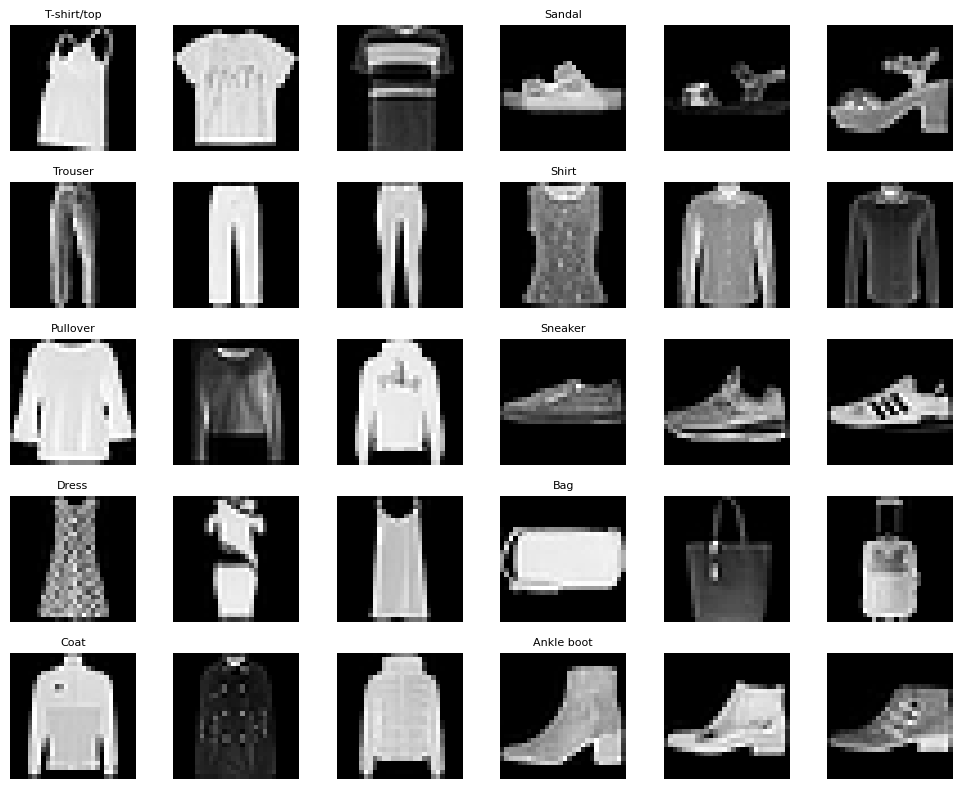

In [113]:
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']
fig, axes = plt.subplots(5, 6, figsize=(10, 8))
for cls in range(10):
    idxs = np.where(y_train == cls)[0][:3]
    row = cls % 5
    col_offset = (cls // 5) * 3
    for j, idx in enumerate(idxs):
        axes[row, col_offset + j].imshow(X_train[idx].reshape(28, 28), cmap='gray')
        axes[row, col_offset + j].axis('off')
        if j == 0:
            axes[row, col_offset].set_title(class_names[cls], fontsize=8)
plt.tight_layout()
plt.savefig('samples_figures.png', dpi=150, bbox_inches='tight') 

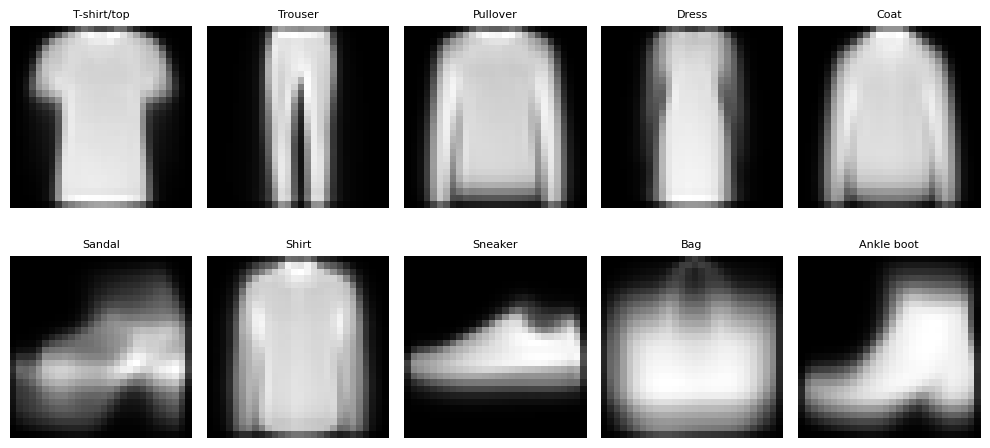

In [114]:
all_X = np.concatenate([X_train, X_val, X_test])
all_y = np.concatenate([y_train, y_val, y_test])


fig, axes = plt.subplots(2, 5, figsize=(10, 5))
avg_images = []
for cls in range(10):
    idxs = np.where(all_y == cls)
    image = np.mean(all_X[idxs], axis=0).reshape(28, 28)
    avg_images.append(image)
    axes[cls // 5, cls % 5].imshow(image, cmap='gray')
    axes[cls // 5, cls % 5].axis('off')
    axes[cls // 5, cls % 5].set_title(class_names[cls], fontsize=8)
# plt.suptitle('Figure 1: Average images for each class')
plt.tight_layout()
plt.savefig('fig1_average.png', dpi=150, bbox_inches='tight')


In [119]:
MSE_matrix = np.zeros((10, 10))

for i in range(10):
    for j in range(10):
        MSE_matrix[i, j] = np.mean((avg_images[i] - avg_images[j])**2)

print(MSE_matrix)
print(MSE_matrix[2,4], MSE_matrix[2,6], MSE_matrix[4,6])
print(MSE_matrix[1])
print(MSE_matrix[8])

[[0.         0.05311801 0.03997007 0.0258151  0.04268497 0.11516099
  0.01748155 0.13436508 0.07260438 0.11699576]
 [0.05311801 0.         0.09089468 0.02131639 0.08867205 0.10510694
  0.06225445 0.12461984 0.11976411 0.14704592]
 [0.03997007 0.09089468 0.         0.06540383 0.00770816 0.11595839
  0.00904231 0.12684736 0.04245052 0.09479737]
 [0.0258151  0.02131639 0.06540383 0.         0.05973765 0.09999257
  0.03543994 0.11560864 0.08518409 0.12103403]
 [0.04268497 0.08867205 0.00770816 0.05973765 0.         0.13636693
  0.01169093 0.14229478 0.04738765 0.1062208 ]
 [0.11516099 0.10510694 0.11595839 0.09999257 0.13636693 0.
  0.08784107 0.01895315 0.07175377 0.06281976]
 [0.01748155 0.06225445 0.00904231 0.03543994 0.01169093 0.08784107
  0.         0.10295123 0.03649849 0.08520459]
 [0.13436508 0.12461984 0.12684736 0.11560864 0.14229478 0.01895315
  0.10295123 0.         0.07007564 0.06632367]
 [0.07260438 0.11976411 0.04245052 0.08518409 0.04738765 0.07175377
  0.03649849 0.07007

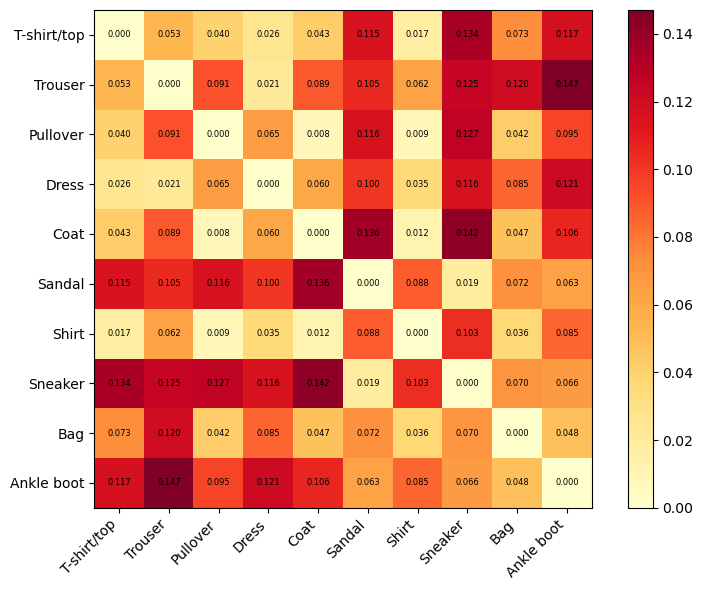

In [116]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(MSE_matrix, cmap='YlOrRd')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
for i in range(10):
    for j in range(10):
        ax.text(j, i, f'{MSE_matrix[i,j]:.3f}', 
                ha='center', va='center', fontsize=6)
plt.colorbar(im, ax=ax)
# ax.set_title('Figure 2: Pairwise MSE between class average images')
plt.tight_layout()
plt.savefig('fig2_mse_heatmap.png', dpi=150, bbox_inches='tight')

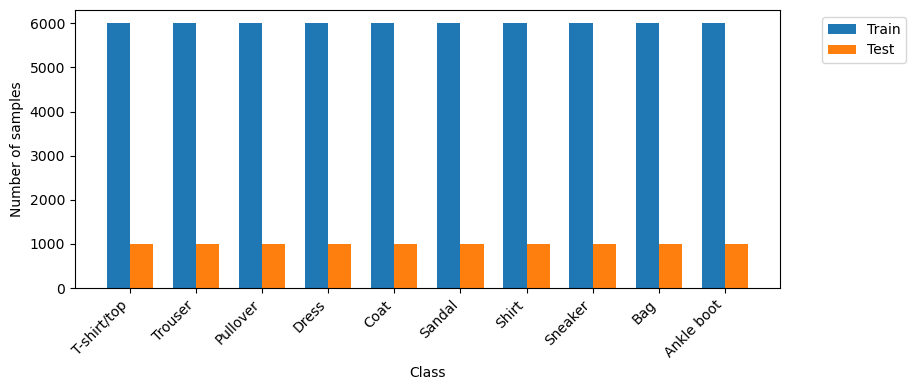

In [117]:
fig, ax = plt.subplots(figsize=(8, 4))
ori_y_train = np.concatenate([y_train, y_val])
counts_ori_tr = [np.sum(ori_y_train == i) for i in range(10)]
counts_ori_te = [np.sum(y_test == i) for i in range(10)]

width = 0.35
x = np.arange(10)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')

ax.bar(x - width/2, counts_ori_tr, width, label='Train')
ax.bar(x + width/2, counts_ori_te, width, label='Test')
ax.set_xlabel('Class')
ax.set_ylabel('Number of samples')
# ax.set_title('Figure 2: Class distribution in training and testing set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('distribution.png', dpi=150, bbox_inches='tight')
